# mSSA Run

## Importing Packages

In [183]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
import importlib
sys.path.append('../code/')
import helper

In [3]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams.update({
    'axes.linewidth': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    "lines.color": "white",
    "patch.edgecolor": "white",
    "text.color": "black",
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white"})

## Loading In Files

In [185]:
directory = '../data/mSSA_channels_live_t280-480/'

all_m1_rel_amp_ = np.loadtxt(directory+'m1_amp_rel_bins_j30_t16.dat')

all_m1_rel_amp = all_m1_rel_amp_[:,1:]

outer_m1_rel_amp = all_m1_rel_amp[:,240:]
inner_m1_rel_amp = all_m1_rel_amp[:,:256]

In [186]:
np.savetxt(directory+ 'm1_amp_rel_bins_j15_t16_outer.dat',
           np.hstack([np.reshape(all_m1_rel_amp_[:,0], (len(all_m1_rel_amp_[:,0]), 1)), outer_m1_rel_amp]))
np.savetxt(directory+ 'm1_amp_rel_bins_j15_t16_inner.dat',
           np.hstack([np.reshape(all_m1_rel_amp_[:,0], (len(all_m1_rel_amp_[:,0]), 1)), inner_m1_rel_amp]))

In [187]:
fname_m1_rel_amp = directory+'m1_amp_rel_bins_j15_t16_inner.dat'

coefs_m1_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_rel_amp)

coefs_m1_rel_amp = coefs_m1_rel_amp0.deepcopy()

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [188]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m1_rel_amp.getAllCoefs()))
times = coefs_m1_rel_amp.Times()

keylst_m1_amp = [[i] for i in range(n_channels)]

config = {"snails_m1_amp_rel": (coefs_m1_rel_amp, keylst_m1_amp, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

## mSSA Analysis

In [189]:
fig_dir = '../figures/kiyan_live_figures/m1_rel_amp_inner/'

In [190]:
ev = mssa.eigenvalues()

shape U = 25600 x 101
shape Y = 101 x 25600


In [191]:
coefs_m1_rel_amp.zerodata()
mssa.reconstruct([*range(30)])

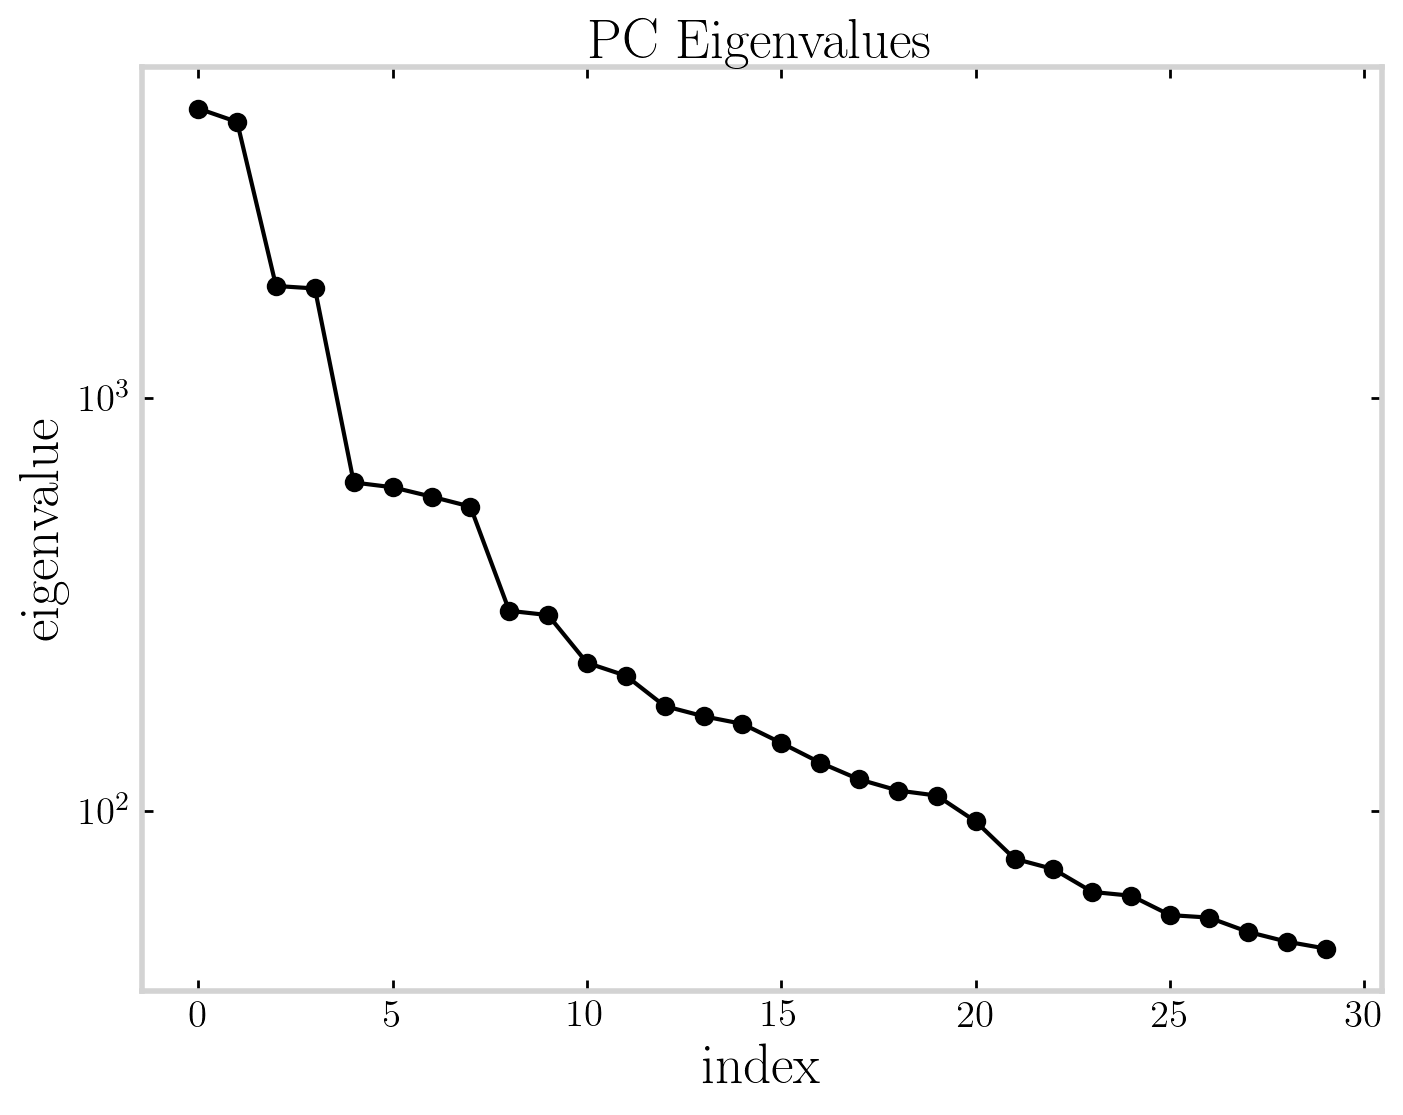

In [193]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.semilogy(ev[:30], '-o')

ax1.set_xlabel('index', fontsize=20)
ax1.set_ylabel('eigenvalue', fontsize=20)
    
ax1.set_title('PC Eigenvalues', fontsize=20)
#plt.savefig(fig_dir+'eigenvalues.pdf')
#plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

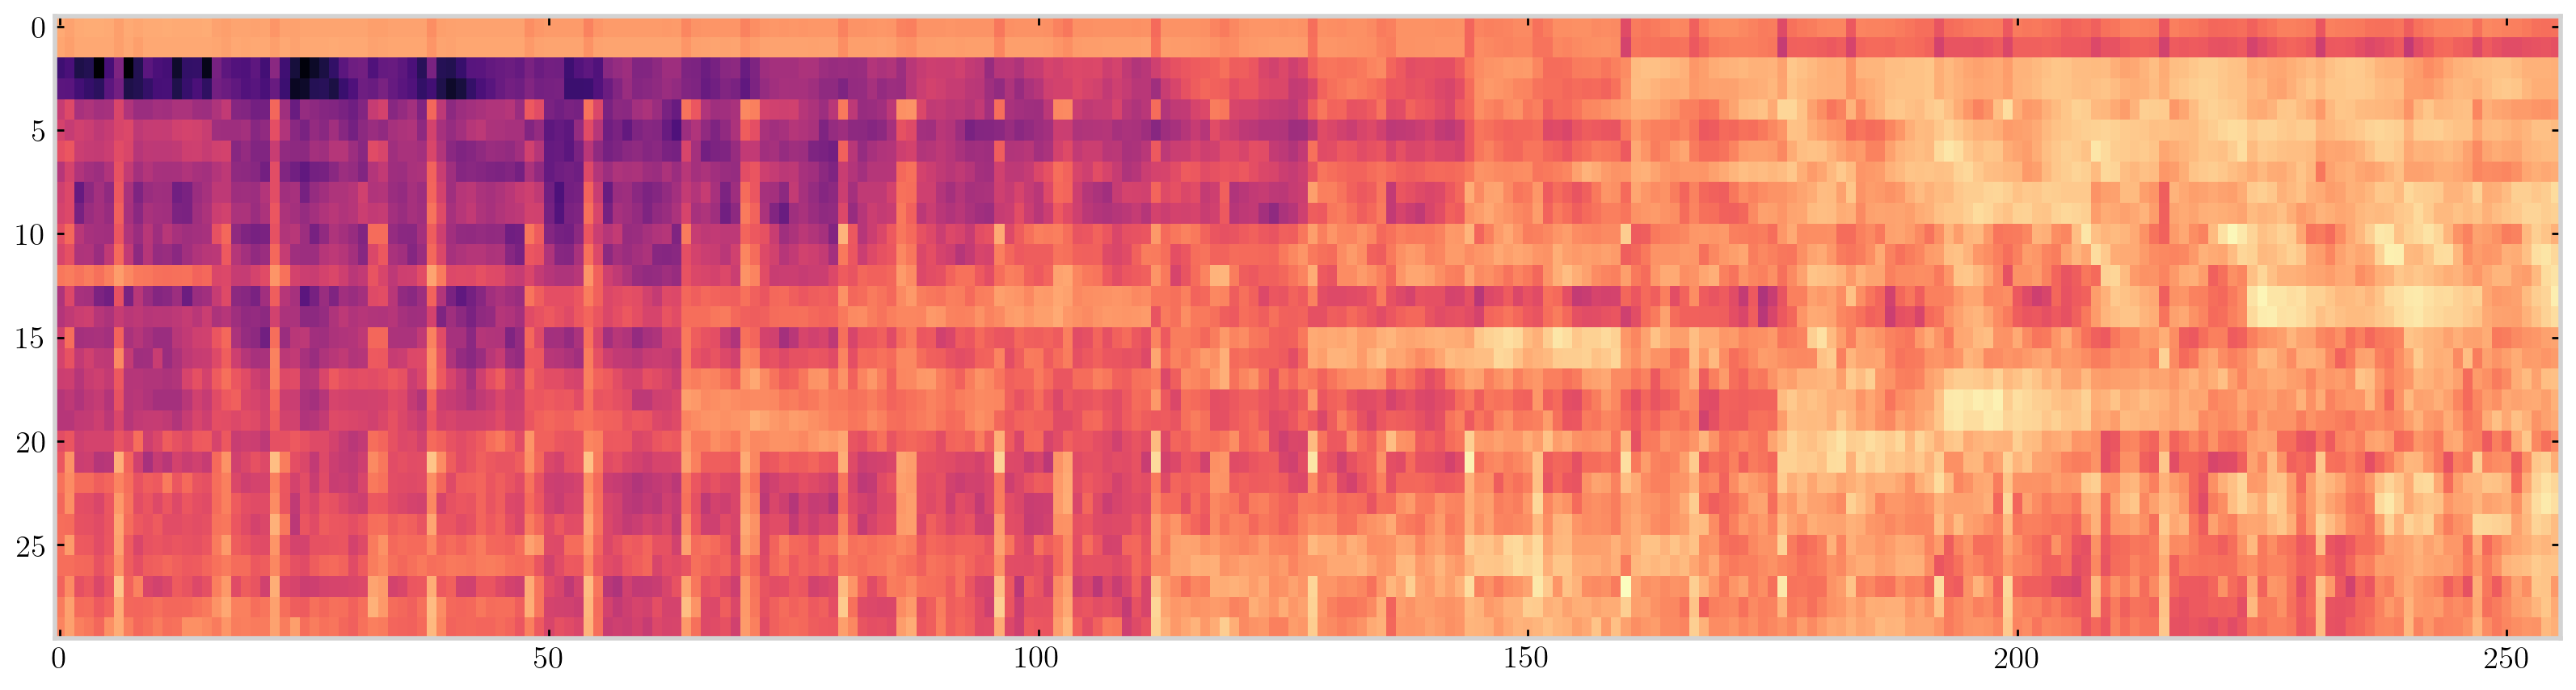

In [194]:
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t2, aspect='auto', norm=mpl.colors.LogNorm())

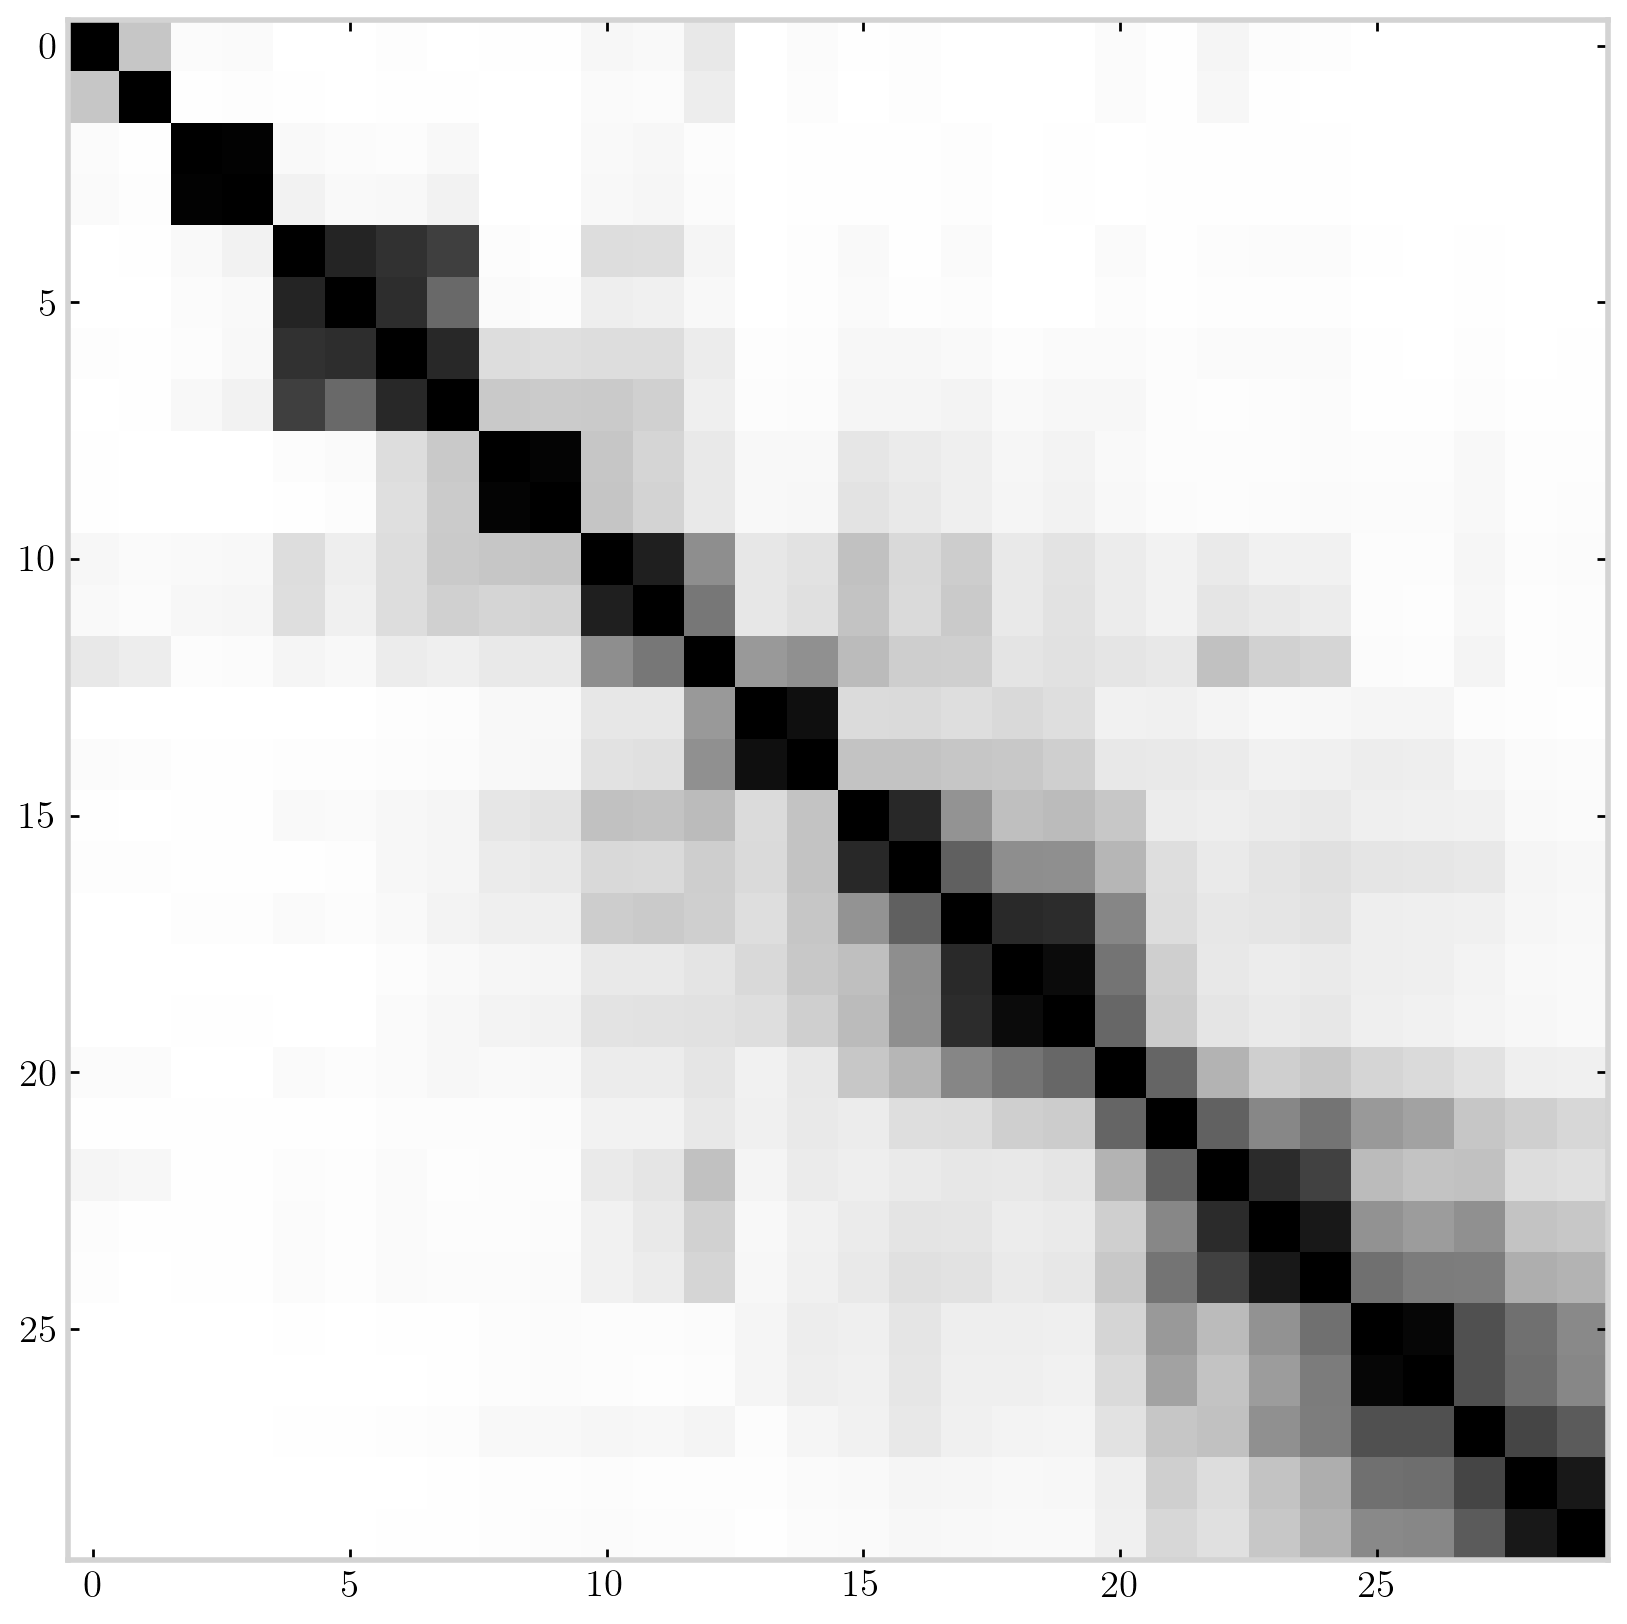

In [195]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), sharey=True)

ax.imshow(mssa.wCorrAll()[:30, :30], cmap='gray_r')
#plt.savefig(fig_dir+'wCorr30.pdf')
#plt.savefig(fig_dir+'wCorr30.png') 
plt.show()

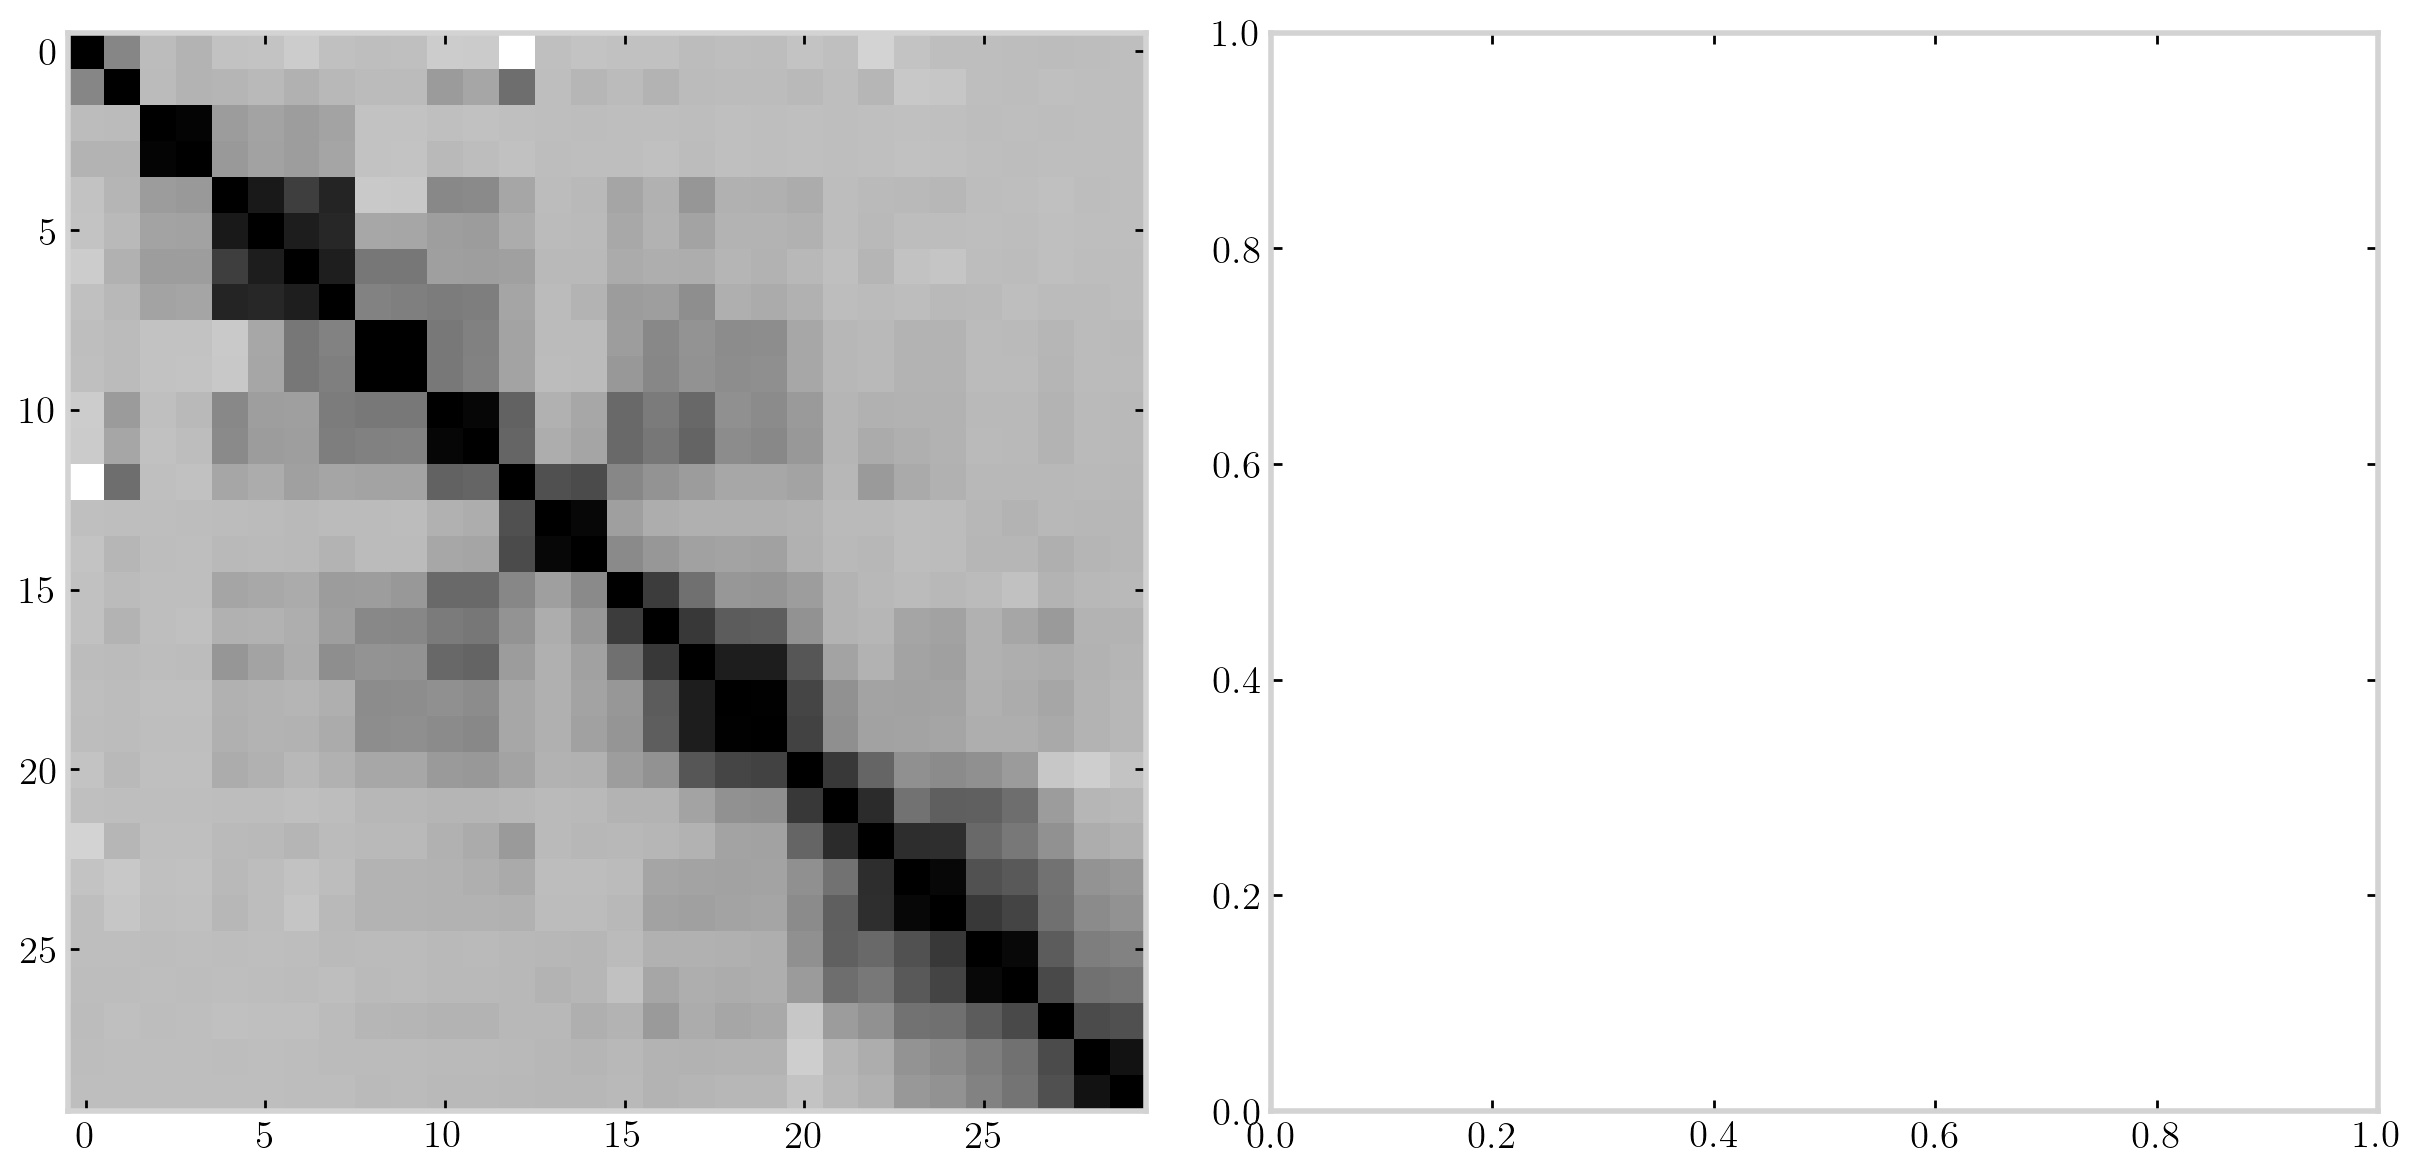

In [196]:
# wCorr for amplitude:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15,7))
ax1.imshow(mssa.wCorrKey([0]), cmap='gray_r')
#ax2.imshow(mssa.wCorrKey([1]), cmap='gray_r')
plt.show()

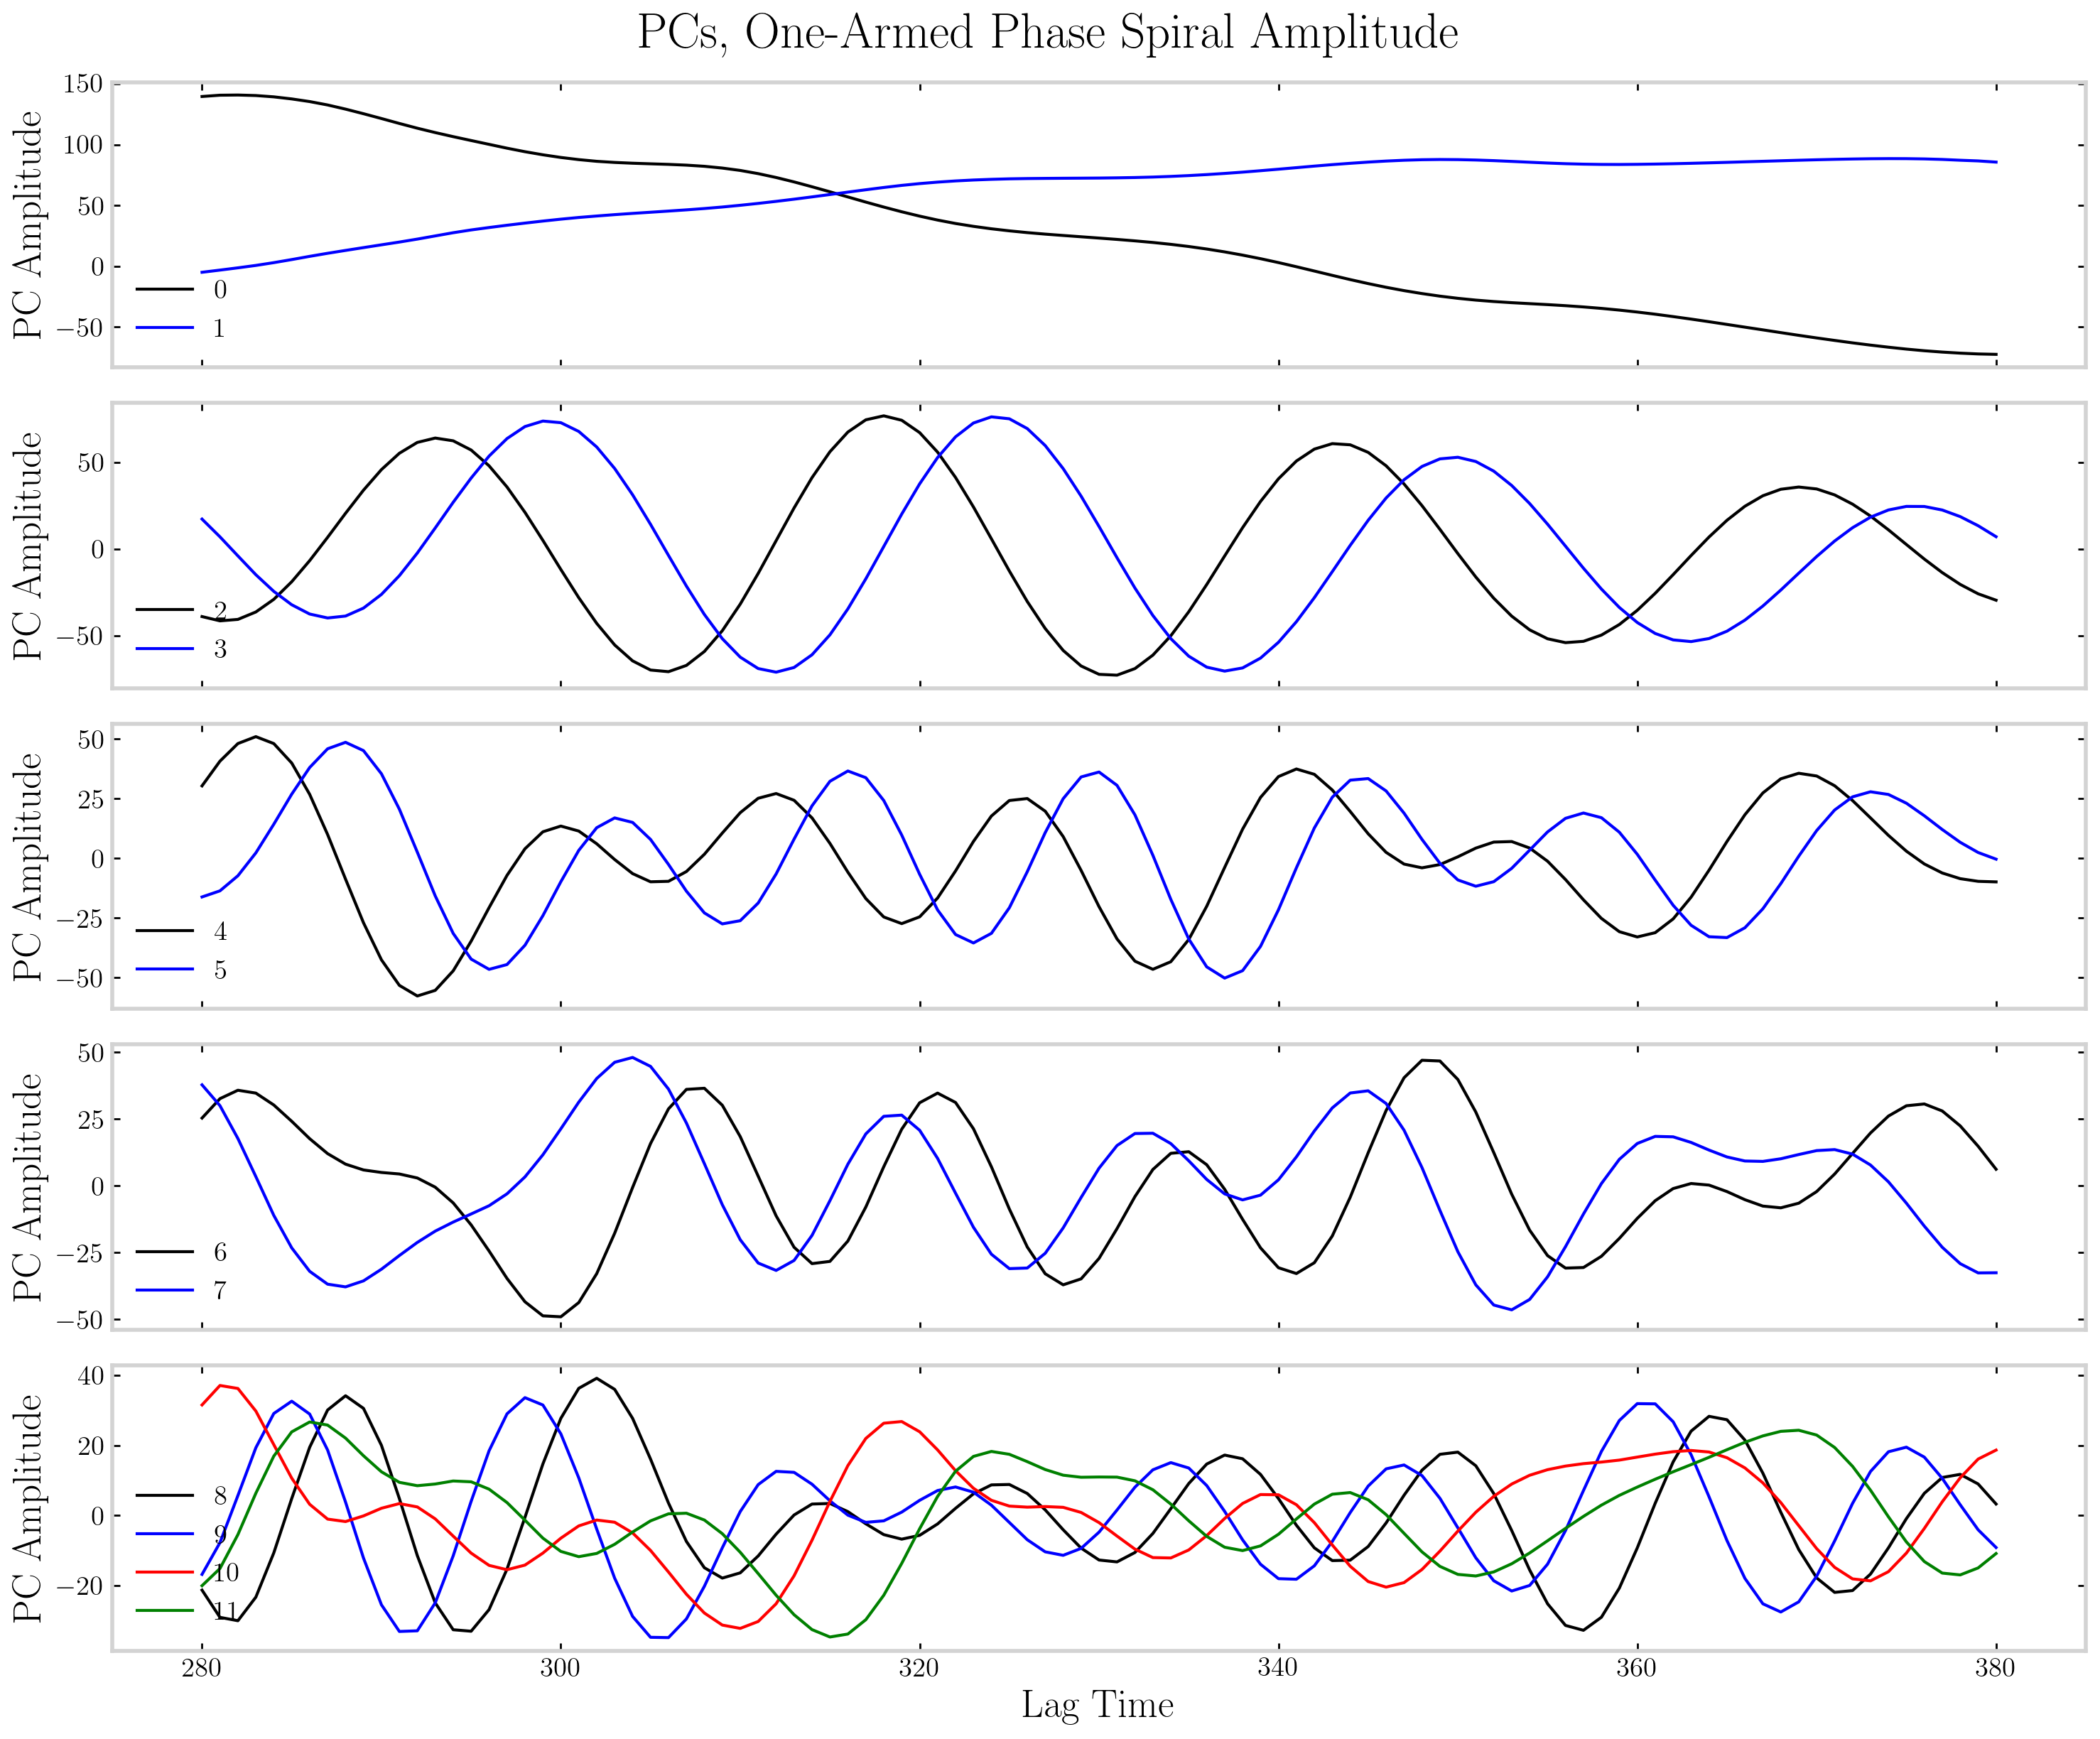

In [197]:
%matplotlib inline
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(15, 2.5*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

plt.suptitle('PCs, One-Armed Phase Spiral Amplitude', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

for i in range(n_plots):
    axs[i].set_ylabel('PC Amplitude', fontsize=20)
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

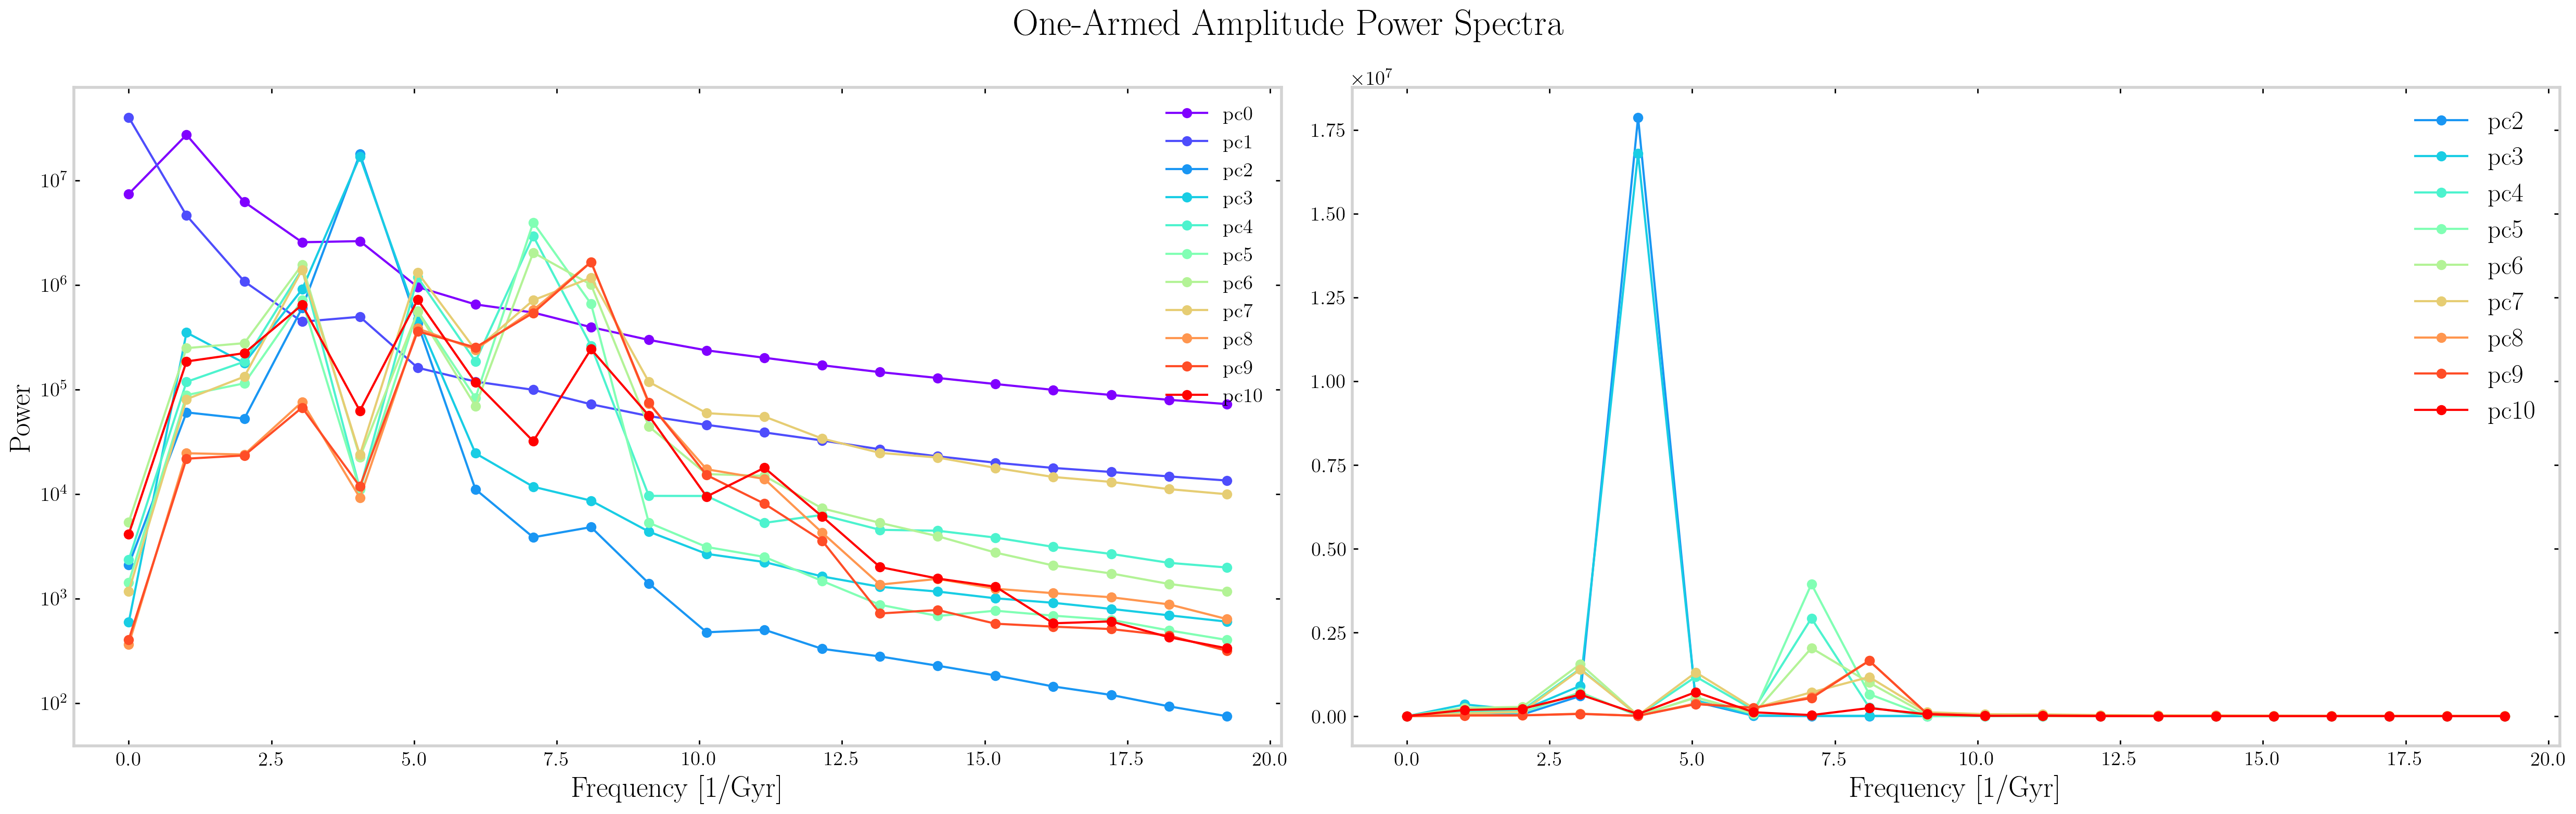

In [198]:
freq, power = mssa.pcDFT()
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(25, 8))

color = iter(cm.rainbow(np.linspace(0, 1, 11)))
    
for i in range(0, 11,1):
    c = next(color)
    ax1.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

    if i>=2:
        ax2.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

ax1.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax2.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax1.legend() ; ax2.legend(fontsize=18)
ax1.set_ylabel('Power', fontsize=20)
ax1.set_yscale('log')

plt.suptitle('One-Armed Amplitude Power Spectra', fontsize=25)
fig.tight_layout()
#plt.savefig(fig_dir+'power_spectrum.pdf')
plt.show()

## Face-on Plots

Updating for: (c)_0
Updating for: (s)_0
Updating for: (`)_0
Updating for: (J)_0
256
Updating for: (_)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (~)_0
Updating for: (�)_0
Updating for: (i)_0
Updating for: (})_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (>)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (L)_0
Updating for: (_)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (!)_0
Updating for: (B)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( 

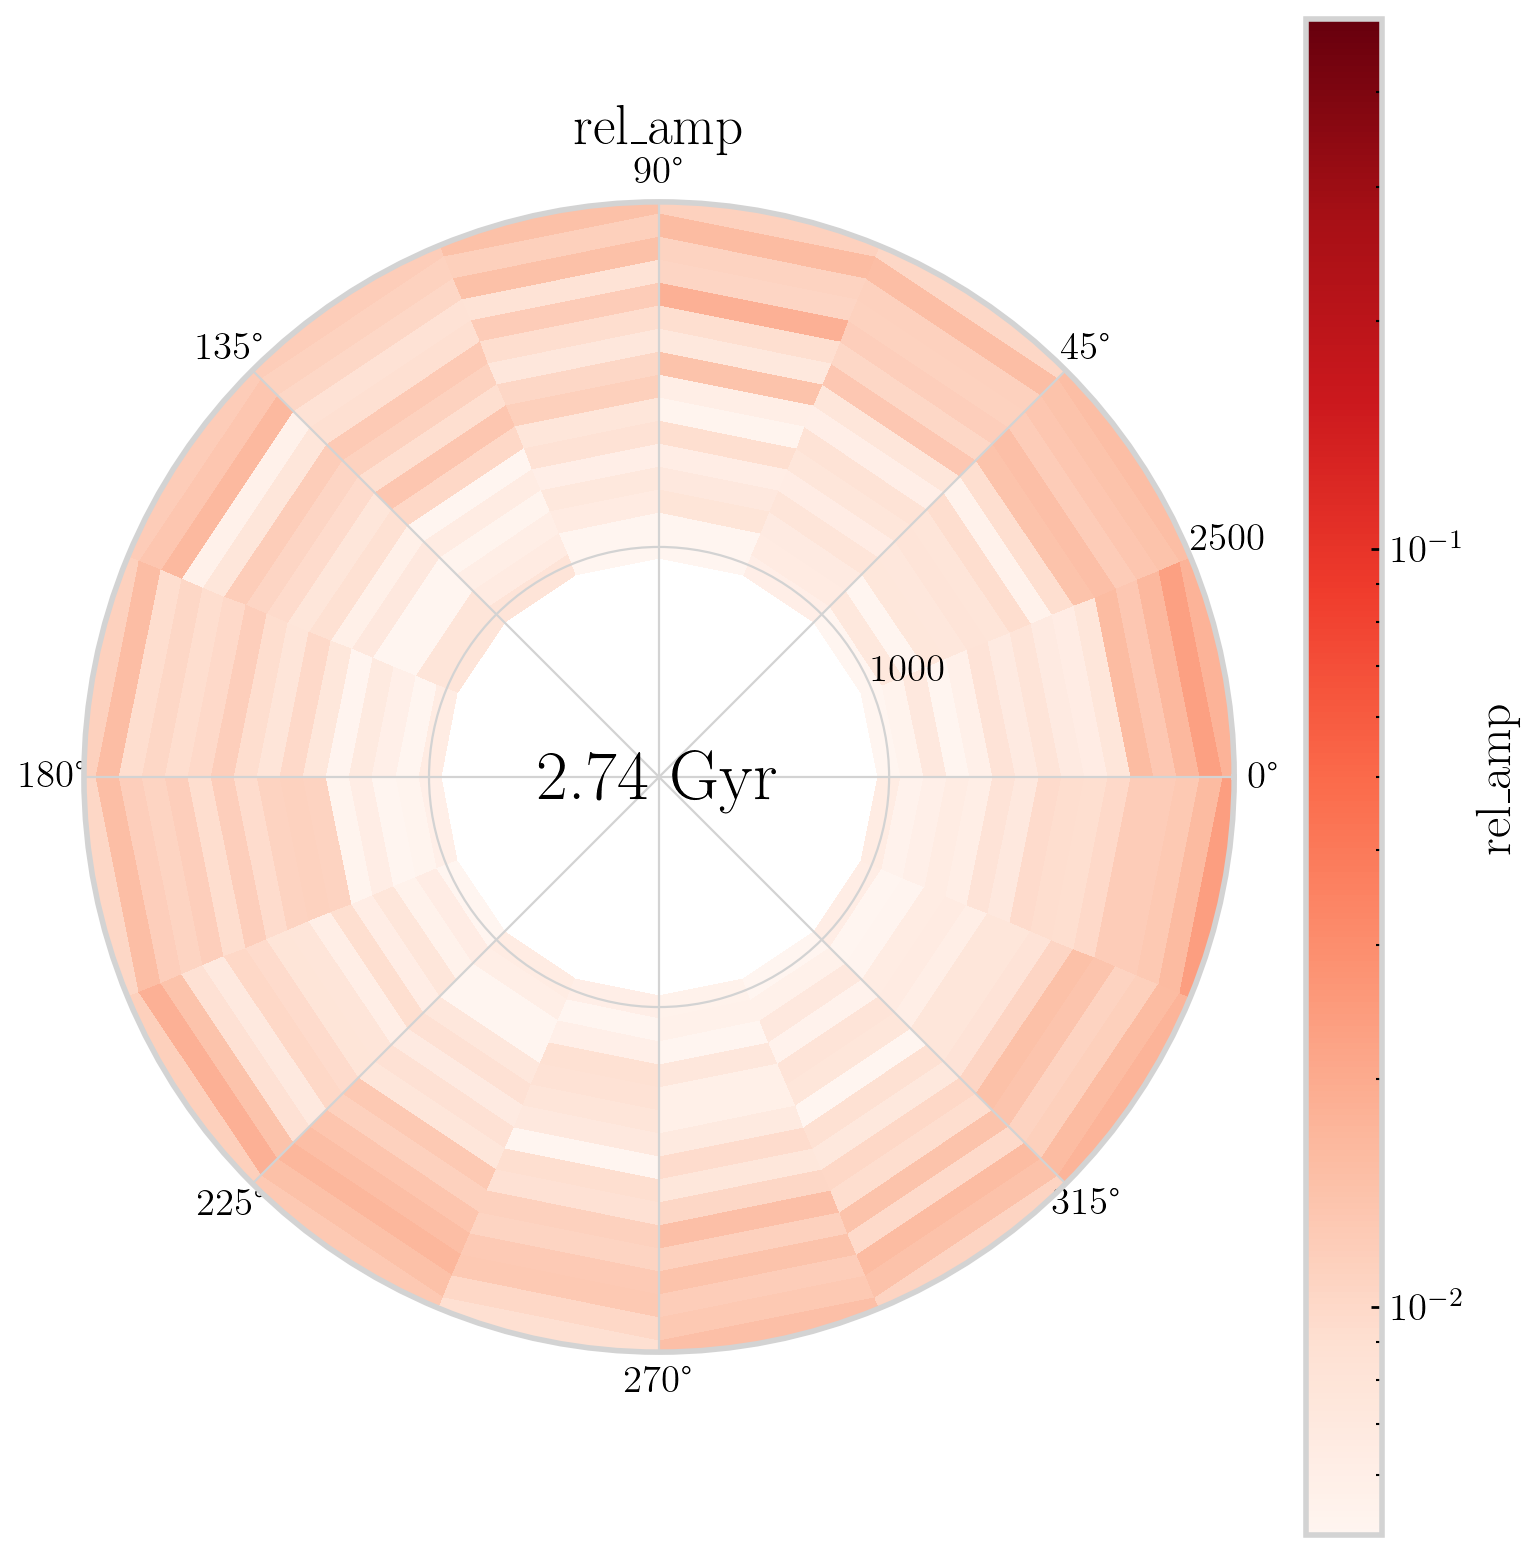

In [202]:
importlib.reload(sys.modules['helper'])
from helper import *

tbl_rel_amp = np.loadtxt(directory+'m1_amp_rel_bins_j15_t16_inner.dat')

f = fig_dir+'face-on_plots/data_rel_amp.mp4'

tdict = {'rel_amp': tbl_rel_amp}
MakeAnim = MakeAnimations(mssa, 'rel_amp', times, n_channels, [0,1], jbins=15)
MakeAnim.make_pre_mssa_face_on(f, tdict)

Updating for: (c)_0
256
Making movies for just Amplitude or Pitch Angle
Updating for: (s)_0
Updating for: (`)_0
Updating for: (J)_0
Updating for: (_)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (~)_0
Updating for: (')_0
Updating for: (�)_0
Updating for: (4)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (>)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (L)_0
Updating for: (_)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (!)_0
Updating for: (B)_0
Updating for: ()_0
Updating

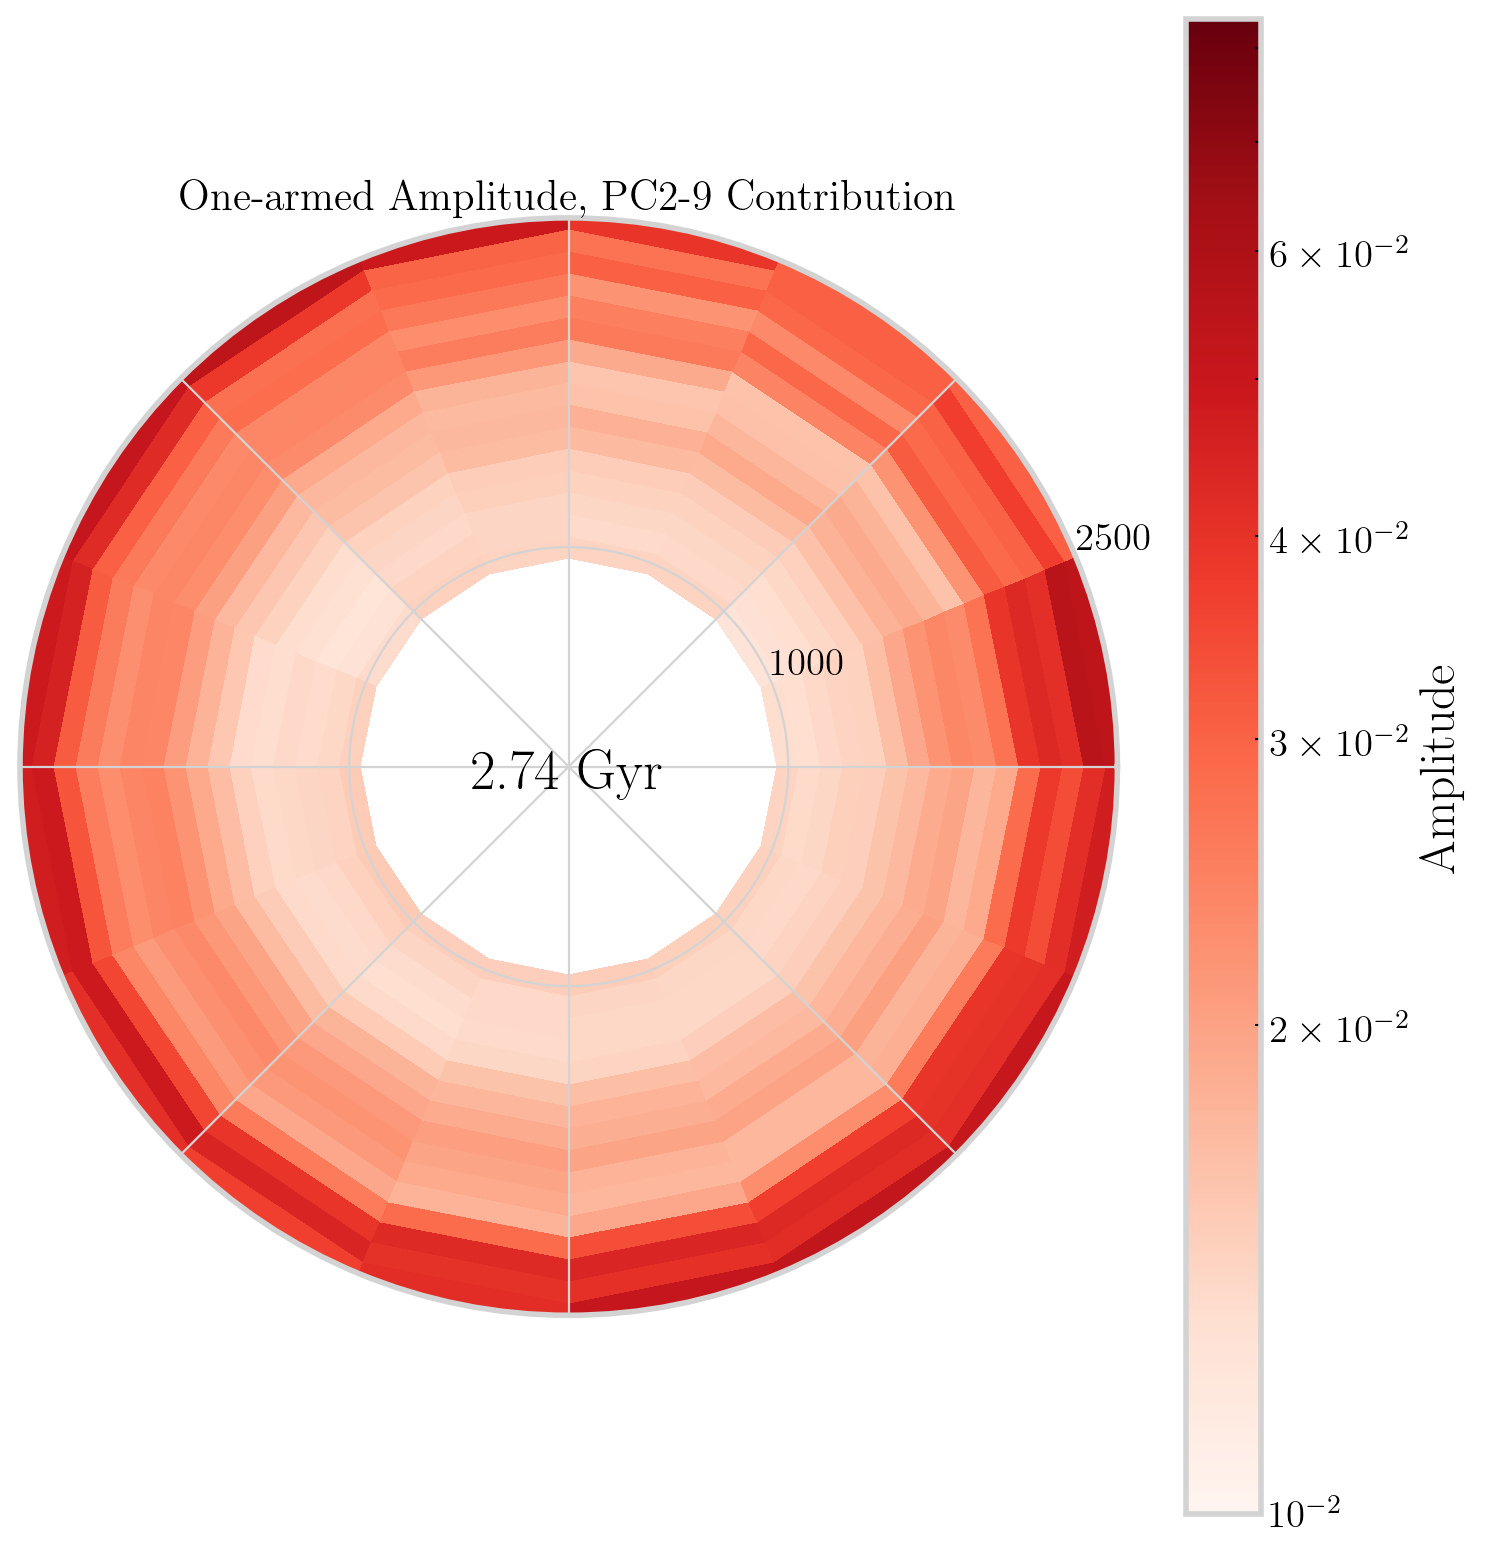

In [261]:
importlib.reload(sys.modules['helper'])
from helper import *

# f = fig_dir+'face-on_plots/pc0+pc1.mp4'
# MakeAnim0 = MakeAnimations(mssa, 'rel_amp', times, n_channels, [0,1], jbins=15)
# MakeAnim0.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc2+pc3.mp4'
# MakeAnim1 = MakeAnimations(mssa, 'rel_amp', times, n_channels, [2,3], jbins=15)
# MakeAnim1.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc4-7.mp4'
# MakeAnim2 = MakeAnimations(mssa, 'rel_amp', times, n_channels, [4,5,6,7], jbins=15)
# MakeAnim2.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc8+pc9.mp4'
# MakeAnim3 = MakeAnimations(mssa, 'rel_amp', times, n_channels, [8,9], jbins=15)
# MakeAnim3.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc0-3.mp4'
# MakeAnim5 = MakeAnimations(mssa, 'rel_amp', times, n_channels, list(range(4)), jbins=15)
# MakeAnim5.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc0-7.mp4'
# MakeAnim6 = MakeAnimations(mssa, 'rel_amp', times, n_channels, list(range(8)), jbins=15)
# MakeAnim6.make_recon_mov_disk_plot(f)

# f = fig_dir+'face-on_plots/pc0-16.mp4'
# MakeAnim7 = MakeAnimations(mssa, 'rel_amp', times, n_channels, list(range(16)), jbins=15)
# MakeAnim7.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc2-9.mp4'
MakeAnim8 = MakeAnimations(mssa, 'rel_amp', times, n_channels, list(range(2,10)), jbins=15)
MakeAnim8.make_recon_mov_disk_plot(f)

### Re-winding to a "Dipole"

In [221]:
# To get colorbar
jphi_c = np.linspace(1000, 2500, 15+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

In [222]:
# Take Reconstructions

mssa.reconstruct(list(range(2,8)))
get_recon = mssa.getReconstructed()

recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
pc_rc = recon_amp_

#recon_pitch_ = get_recon[list(get_recon.keys())[1]].getAllCoefs()
#recon_pitch = recon_pitch_ - np.mean(recon_pitch_, axis=0)

# what is omega_phi at each radius, in rad/Gyr?
freqs = np.load('../data/live_frequency_array_j30.npy')[:16]
omega_phi = freqs*2*np.pi

ratio = 0.009778

Updating for: (c)_0
Updating for: (s)_0
Updating for: ()_0
Updating for: (N)_0
Updating for: (_)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (
)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (|)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (>)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (0)_0
Updating for: (P)_0
Updating for: (_)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (!)_0
Updating for: (B)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


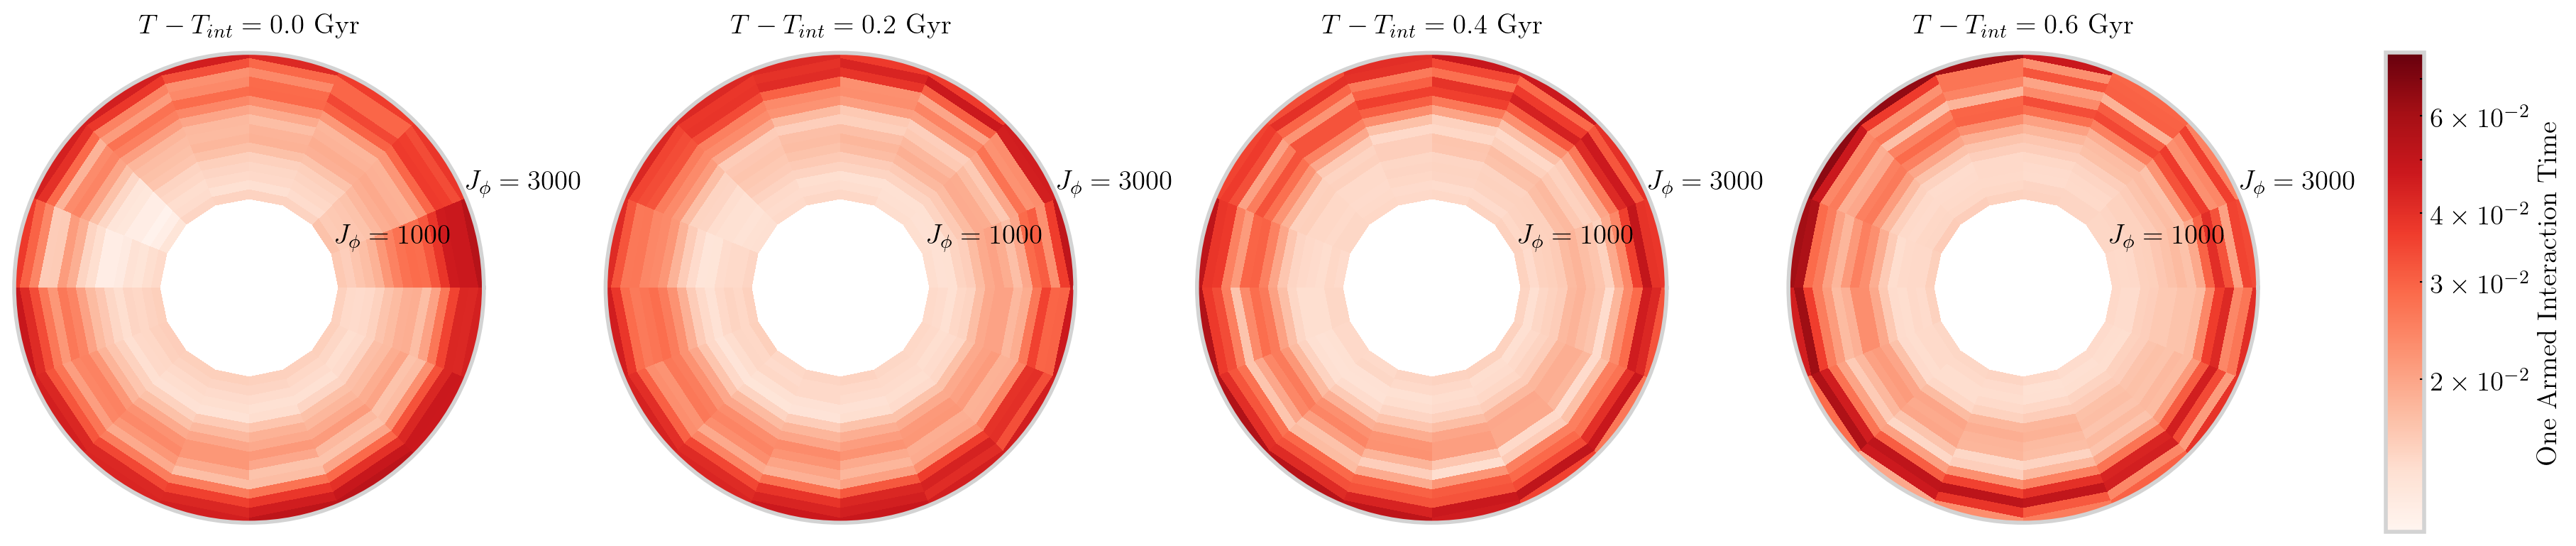

In [223]:
first_timestep = 3
fig, [ax1, ax2, ax3, ax4] = plt.subplots(1, 4, figsize=(18, 4.5), subplot_kw={'projection': 'polar'})

timestep=first_timestep+0
# pc_rc_amp = pc_rc[:n_channels] 
# pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
# rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)
# amp_vmax=0.5

im1 = ax1.pcolormesh(T, J, np.reshape(pc_rc[:,timestep], T.shape, 'F'), 
                          cmap='Reds', rasterized=True,
                          norm=mpl.colors.LogNorm(vmin=max(np.min(pc_rc), 1e-2), vmax=np.max(pc_rc)))
ax1.set_title(r'$T - T_{int} = 0.0$ Gyr', pad=10, fontsize=14)



timestep=first_timestep+20
# pc_rc_amp = pc_rc[:n_channels] 
# pc_rc_amp = pc_rc_amp - np.mean(pc_rc, axis=0)
# rad_mean_amp = np.mean(np.reshape(pc_rc[:,timestep], T.shape, 'F'), axis=0)
# amp_vmax=0.5

im2 = ax2.pcolormesh(T, J, np.reshape(pc_rc[:,timestep], T.shape, 'F'), 
                          cmap='Reds', rasterized=True,
                          norm=mpl.colors.LogNorm(vmin=max(np.min(pc_rc), 1e-2), vmax=np.max(pc_rc)))
ax2.set_title(r'$T - T_{int} = 0.2$ Gyr', pad=10, fontsize=14)



timestep=first_timestep+40

im3 = ax3.pcolormesh(T, J, np.reshape(pc_rc[:,timestep], T.shape, 'F'), 
                          cmap='Reds', rasterized=True,
                          norm=mpl.colors.LogNorm(vmin=max(np.min(pc_rc), 1e-2), vmax=np.max(pc_rc)))
ax3.set_title(r'$T - T_{int} = 0.4$ Gyr', pad=10, fontsize=14)


timestep=first_timestep+60

im5 = ax4.pcolormesh(T, J, np.reshape(pc_rc[:,timestep], T.shape, 'F'), 
                          cmap='Reds', rasterized=True,
                         norm=mpl.colors.LogNorm(vmin=max(np.min(pc_rc), 1e-2), vmax=np.max(pc_rc)))
ax4.set_title(r'$T - T_{int} = 0.6$ Gyr', pad=10, fontsize=14)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'])
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)
    ax.grid(visible=False)

            

fig.tight_layout()


fig.subplots_adjust(right=0.89)
cbar_ax = fig.add_axes([0.94, 0.1, 0.015, 0.75])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('One Armed Interaction Time')
# plt.savefig(fig_dir + 'm1_amplitudes_paper.pdf')
plt.show()

In [252]:
jbins=15
ratio = 0.009778

def plot_rewinding_comp(pc_rc, dipole_timestep, future_timestep):
    fig, [ax2, ax3] = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'projection': 'polar'})
    
    # pc_rc_dipole_reshape = np.reshape(pc_rc[:,dipole_timestep], T.shape, 'F')
    # im1 = ax1.pcolormesh(T, J, pc_rc_dipole_reshape - np.mean(pc_rc_dipole_reshape, axis=0), 
    #                      cmap='RdBu_r', rasterized=True,
    #                      norm=mpl.colors.SymLogNorm(linthresh=1e-2, vmin=-0.5, vmax=0.5), shading='nearest')
    
    
    time_elapsed = (future_timestep - dipole_timestep) * ratio
    d_rot = (time_elapsed * omega_phi)
    
    #now interpolate at each radius so that I can use the same grid as before
    interp = scipy.interpolate.interp1d(tphi_c, pc_rc[:,future_timestep].reshape((jbins+1, 16)), axis=1, 
                                        fill_value="extrapolate")
    all_interp = interp((T+d_rot)%(2*np.pi))
    future_grid = np.diagonal(all_interp, axis1=0, axis2=2)
    
    pc_rc_future_reshape = np.reshape(pc_rc[:,future_timestep], T.shape, 'F')
    im2 = ax2.pcolormesh(T, J, pc_rc_future_reshape - np.mean(pc_rc_future_reshape, axis=0), 
                         cmap='RdBu_r', rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=1e-2, vmin=-0.1, vmax=0.1), shading='nearest')
    ax2.set_title(r'$T - T_{int} = 0.75$ Gyr', pad=10, fontsize=14)
    
    #plot what that timestep looks like after subtracting background
    im3 = ax3.pcolormesh(T, J, future_grid - np.mean(future_grid, axis=0), cmap='RdBu_r', rasterized=True,
                         norm=mpl.colors.SymLogNorm(linthresh=1e-2, vmin=-0.1, vmax=0.1), shading='nearest')
    
    
    ax1.set_title(r'$T_{int}$', pad=10, fontsize=14)
    ax3.set_title(r'Rewind from $T - T_{int} = 0.75$ Gyr to Interaction Time', pad=10, fontsize=14)
    
    
    
    for ax in [ax2, ax3]:
        ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=2500$'])
        ax.set_rmax(np.max(jphi_c))
        ax.tick_params(left = False, right = False , labelleft = True ,
                             labelbottom = False, bottom = False)      
        ax.grid(visible=False)
    
    fig.tight_layout()
    
    
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.95, 0.1, 0.015, 0.75])
    cbar = fig.colorbar(im3, cax=cbar_ax)
    cbar.set_label('One-Armed Amplitude (mean subtracted)')
    plt.savefig(fig_dir + 'rewind_m1_time_of_int.png')
    plt.show()

I've got to subtract by the mean so I can see the spirals and dipole

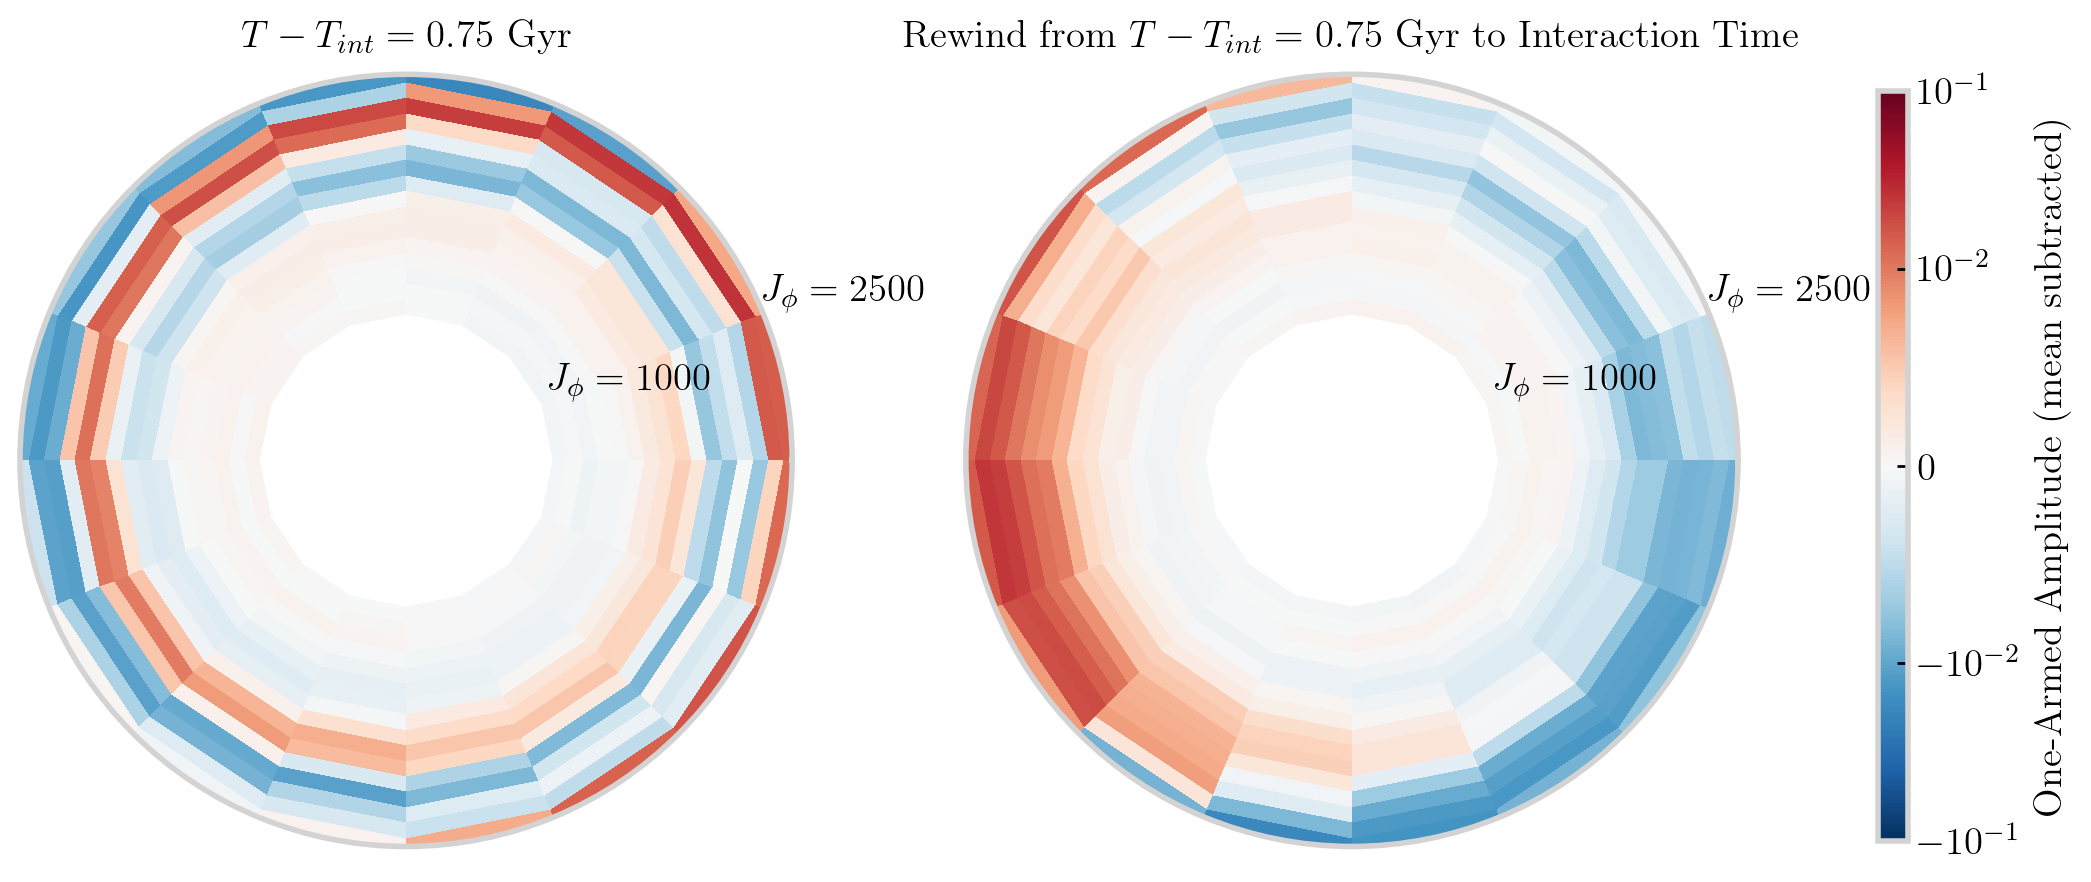

In [250]:
plot_rewinding_comp(pc_rc, dipole_timestep=-23, future_timestep=50)

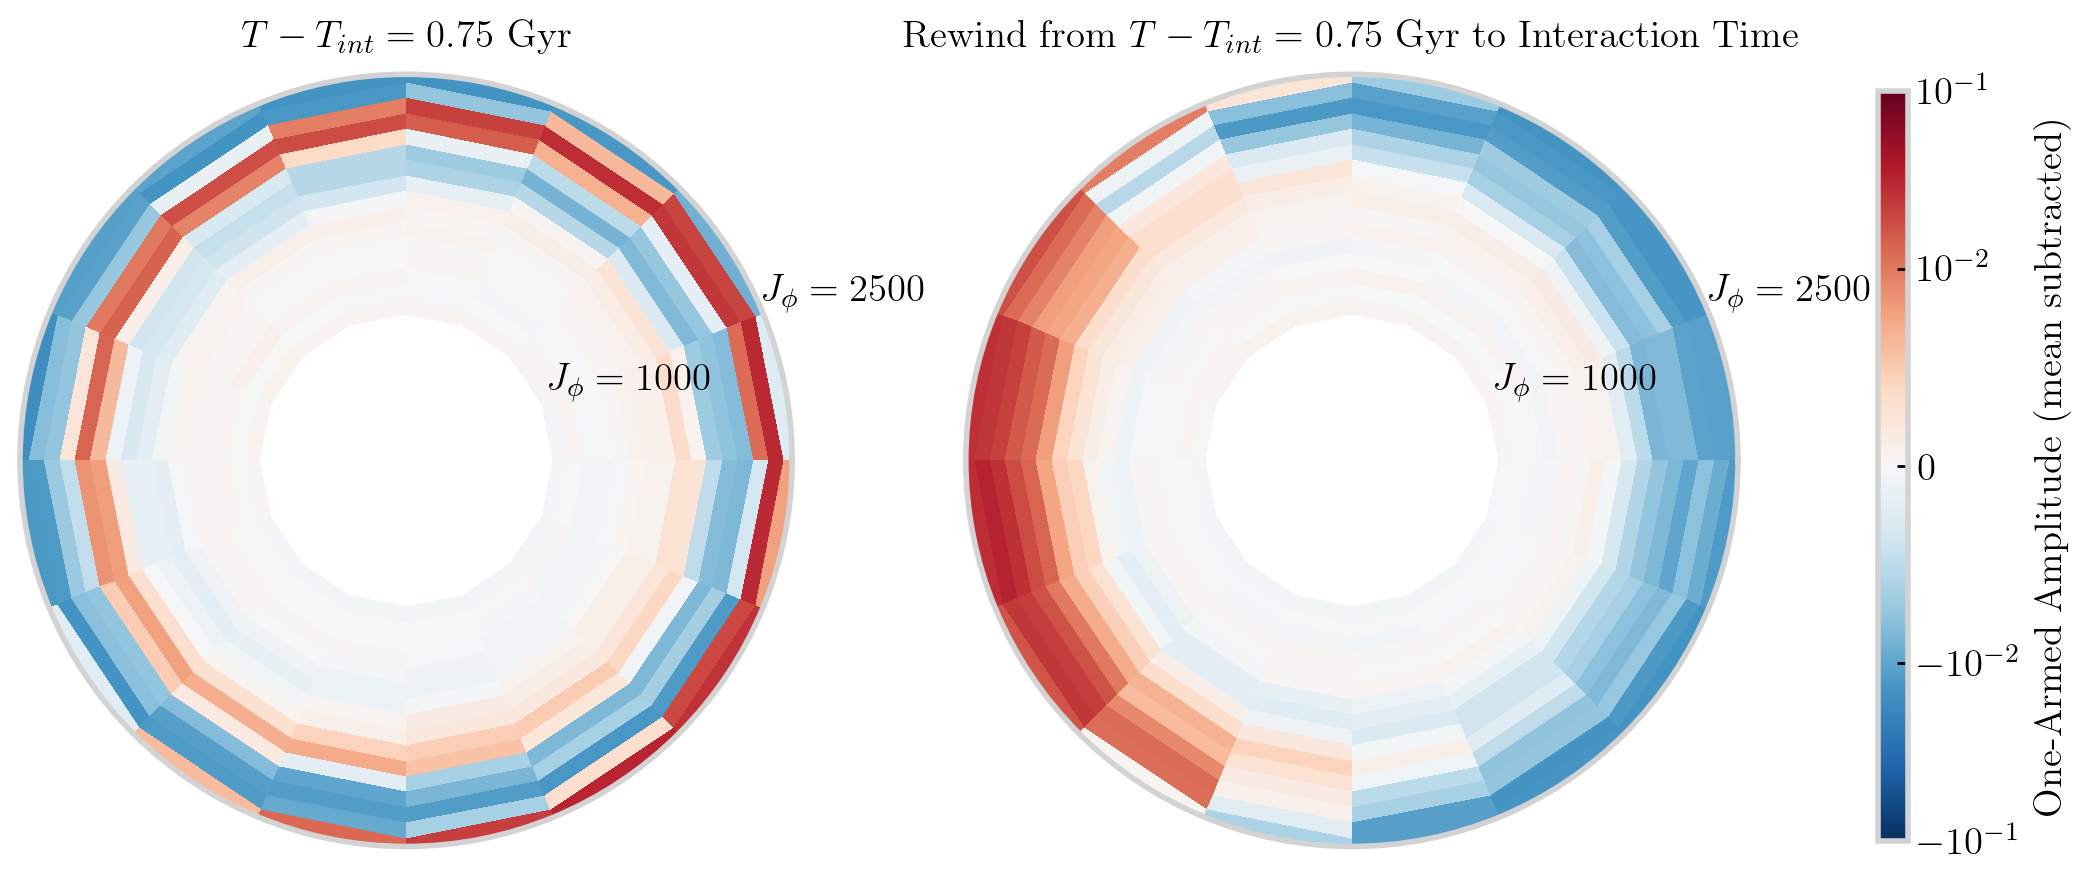

In [260]:
plot_rewinding_comp(pc_rc, dipole_timestep=-23, future_timestep=75)

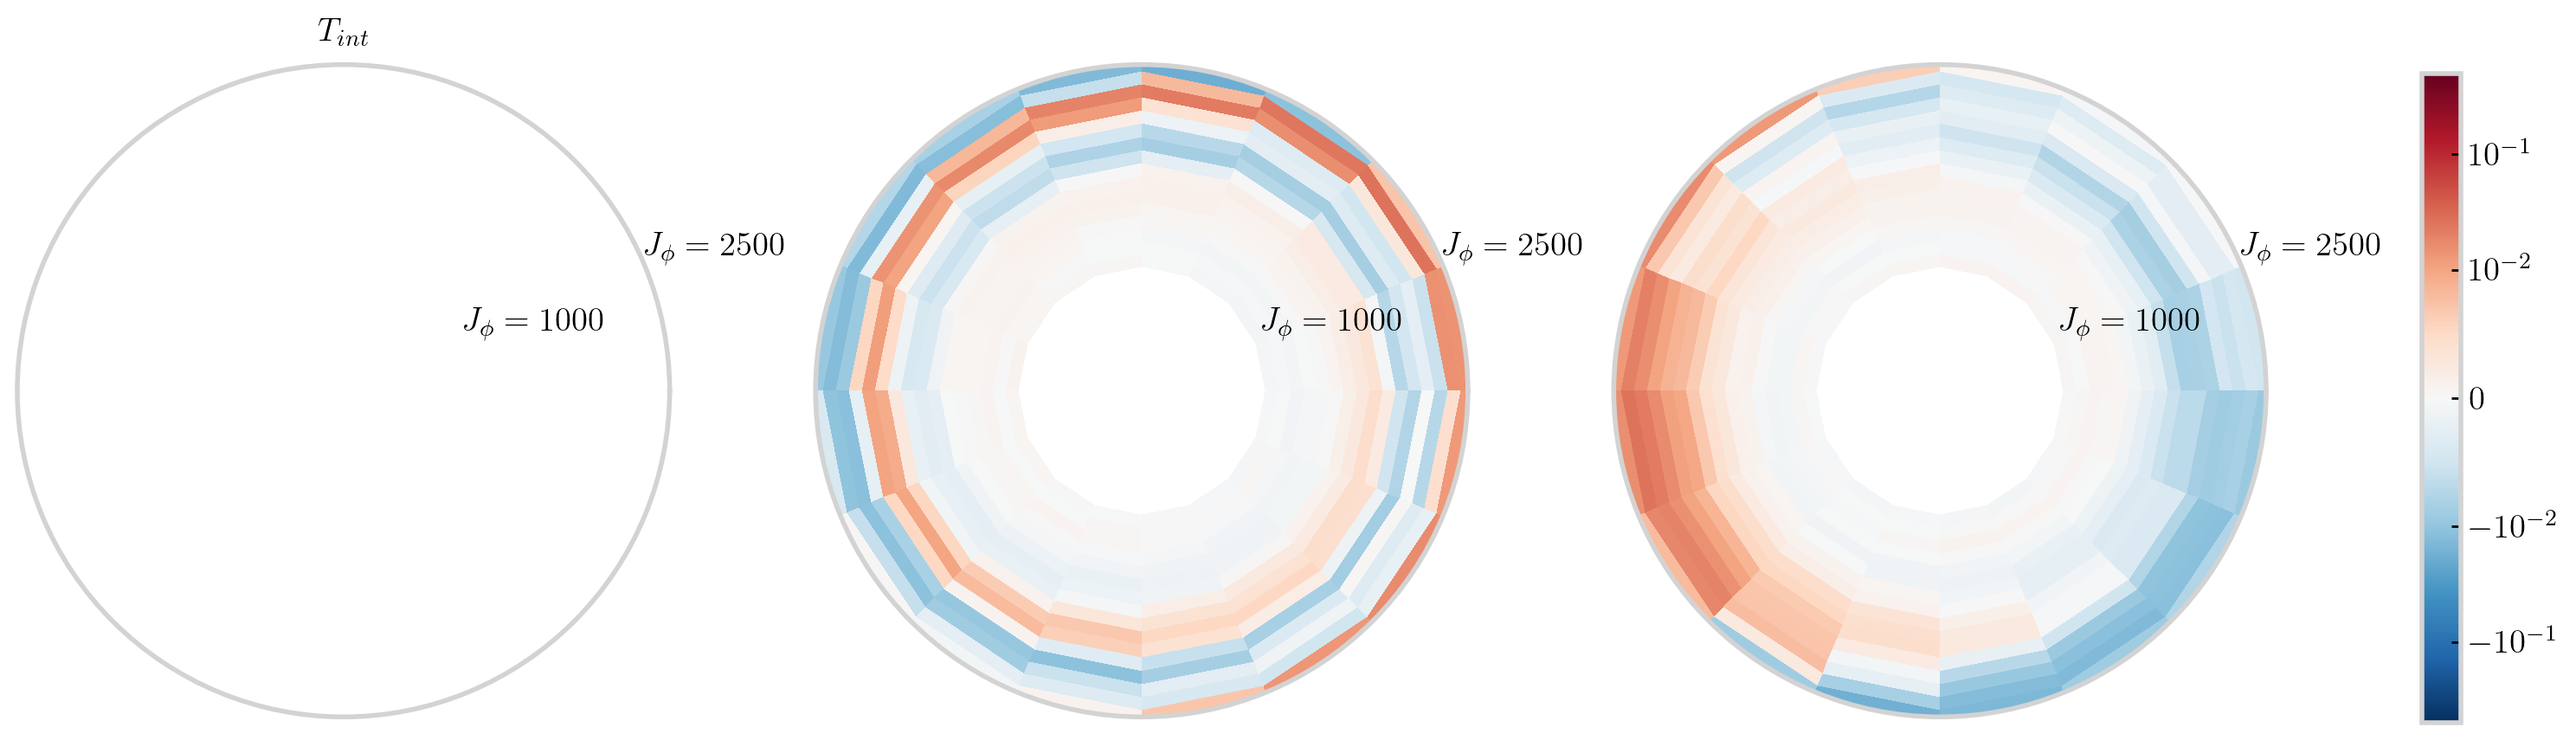

In [233]:
plot_rewinding_comp(pc_rc, dipole_timestep=-23, future_timestep=50)